SVM with Pan-Tompkins algorithm

- Pan-Tompkins algorithm for R-peak detection
- SVM classifier within Pipeline that includes standardization
- GridSearchCV for hyperparameter model tuning of SVM

Loading Lead I from from_006_chkp_2500_150k: 100%|██████████| 2000/2000 [00:42<00:00, 47.15file/s]


Loaded 2000 real ECG records and 2000 fake ECG records.

Extracting features using Pan-Tompkins algorithm...
Feature matrix shape: (4000, 10)

Best Parameters: {'svm__C': 0.1, 'svm__gamma': 'scale'}

Classification Report:
              precision    recall  f1-score   support

        Real       1.00      0.99      1.00       400
   Synthetic       1.00      1.00      1.00       400

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800

AUC-ROC: 1.000


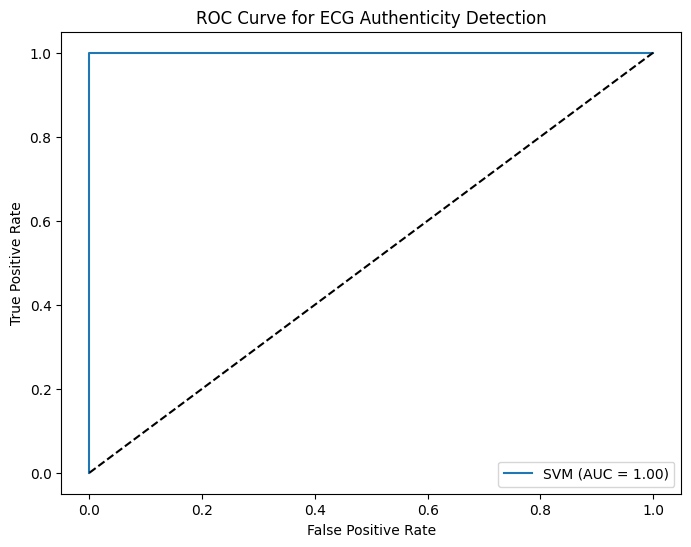

In [1]:
import os
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from biosppy.signals.ecg import engzee_segmenter  # Pan-Tompkins implementation
import matplotlib.pyplot as plt

# =============================================================================
# 0. Data Loading: Define Functions to Load Real and Fake ECG Data
# =============================================================================

def load_lead_I_from_asc(file_path):
    """Load a .asc file and extract Lead I (assumed to be the first column)."""
    try:
        ecg_data = np.loadtxt(file_path)
        lead_I = ecg_data[:, 0]
        return lead_I
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

def load_exactly_n_lead_I_from_directory(data_dir, n=2000):
    """Load exactly n Lead I ECG records from a directory of .asc files."""
    all_lead_I = []
    i = 0
    with tqdm(total=n, desc=f"Loading Lead I from {os.path.basename(data_dir)}", unit='file') as pbar:
        while len(all_lead_I) < n:
            file_name = f"{i}.asc"
            file_path = os.path.join(data_dir, file_name)
            if os.path.exists(file_path):
                lead_I = load_lead_I_from_asc(file_path)
                if lead_I is not None:
                    all_lead_I.append(lead_I)
                    pbar.update(1)
            i += 1
    return np.array(all_lead_I)

# Define dataset directories
DATA_DIR_REAL = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/real_ecgs"
DATA_DIR_FAKE = "C:/Users/M2-Winterfell/Downloads/pulse2pulse_150k/from_006_chkp_2500_150k"

# Load real and fake data (e.g., 2000 records each)
lead_I_real = load_exactly_n_lead_I_from_directory(DATA_DIR_REAL, n=2000)
lead_I_fake = load_exactly_n_lead_I_from_directory(DATA_DIR_FAKE, n=2000)
print(f"Loaded {lead_I_real.shape[0]} real ECG records and {lead_I_fake.shape[0]} fake ECG records.")

# =============================================================================
# 1. Prepare Labels and Combine the Data
# =============================================================================
# Use the number of records loaded to create labels:
n_real = lead_I_real.shape[0]
n_fake = lead_I_fake.shape[0]
# Label 0 for Real, 1 for Synthetic/Fake
y = np.concatenate([np.zeros(n_real), np.ones(n_fake)])

# Combine the real and fake signals into one dataset
lead_I_data = np.concatenate([lead_I_real, lead_I_fake])

# =============================================================================
# 2. Enhanced Feature Extraction using Pan-Tompkins
# =============================================================================
def extract_ecg_features(signal, sampling_rate=500):
    """
    Extract a set of ECG features including:
      - Time-domain features (mean, std, peak-to-peak, IQR)
      - Frequency-domain features (mean FFT power, dominant frequency)
      - Heart rate variability & morphological features using Pan-Tompkins R-peak detection
    """
    features = []
    
    # Time-domain features
    features.append(np.mean(signal))          # Mean amplitude
    features.append(np.std(signal))           # Standard deviation
    features.append(np.ptp(signal))           # Peak-to-peak amplitude
    features.append(np.percentile(signal, 75) - np.percentile(signal, 25))  # IQR
    
    # Frequency-domain features
    fft_vals = np.abs(np.fft.rfft(signal))
    features.append(np.mean(fft_vals))        # Mean spectral power
    features.append(np.argmax(fft_vals))      # Dominant frequency component
    
    # R-peak detection using Pan-Tompkins (engzee_segmenter)
    try:
        r_peaks = engzee_segmenter(signal=signal, sampling_rate=sampling_rate)[0]
        rr_intervals = np.diff(r_peaks) / sampling_rate  # in seconds
        
        if len(rr_intervals) > 1:
            features.append(np.mean(rr_intervals))  # Mean RR interval
            features.append(np.std(rr_intervals))   # SDNN (standard deviation)
            features.append(np.sqrt(np.mean(np.square(np.diff(rr_intervals)))))  # RMSSD
            
            # Morphological feature: Average QRS duration (using a window around R-peaks)
            qrs_durations = []
            for peak in r_peaks:
                start = max(0, peak - 50)
                end = min(len(signal), peak + 50)
                qrs_durations.append(end - start)
            features.append(np.mean(qrs_durations))
        else:
            # If not enough R-peaks, use fallback values
            features.extend([0, 0, 0, 0])
    except Exception as e:
        print(f"R-peak detection error: {e}")
        features.extend([0, 0, 0, 0])
    
    return np.array(features)

print("\nExtracting features using Pan-Tompkins algorithm...")
X_features = np.array([extract_ecg_features(sig) for sig in lead_I_data])
print("Feature matrix shape:", X_features.shape)

# Remove samples with any NaN features (if present)
valid_indices = ~np.any(np.isnan(X_features), axis=1)
X_clean = X_features[valid_indices]
y_clean = y[valid_indices]

# =============================================================================
# 3. Data Preprocessing, Hyperparameter Tuning, and Model Training
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, 
    test_size=0.2, 
    stratify=y_clean,
    shuffle=True,
    random_state=42
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, class_weight='balanced'))
])

param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.1, 1]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nBest Parameters:", grid_search.best_params_)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Real', 'Synthetic']))

auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.3f}")

# =============================================================================
# 4. ROC Curve Plotting
# =============================================================================
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'SVM (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for ECG Authenticity Detection')
plt.legend()
plt.show()


动态时间规整（Dynamic Time Warping）：比较ECG信号的形态相似性，真人ECG信号的形态通常更复杂，而机器人生成的ECG可能过于平滑

Template Matching and signal similarity and distance-based comparison and Random Forest for classification

- Measure the similarity between ECG signals by comparing them to multiple real ECG templates
- Calculating the pairwise DTW distances between the signals and randomly chosen templates
- resulting distance matrix used as features for training a Random Forest(RF) classifier

Loading Lead I from from_006_chkp_2500_150k: 100%|██████████| 2000/2000 [00:31<00:00, 63.73file/s]


Total Lead I records loaded from real data: 2000
Total Lead I records loaded from fake data: 2000
              precision    recall  f1-score   support

         0.0       0.72      0.76      0.74       400
         1.0       0.74      0.70      0.72       400

    accuracy                           0.73       800
   macro avg       0.73      0.73      0.73       800
weighted avg       0.73      0.73      0.73       800



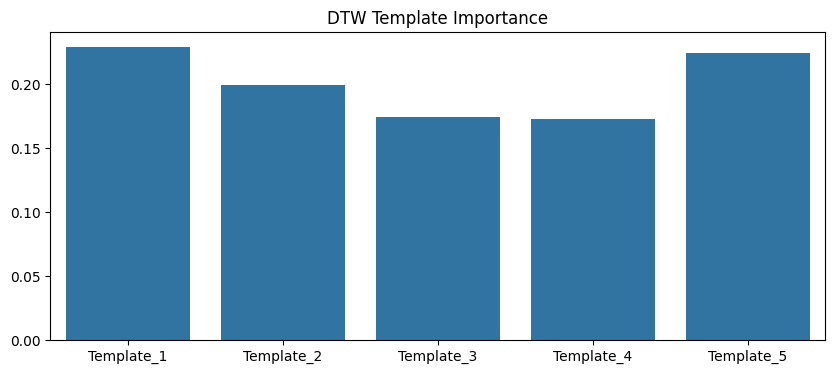

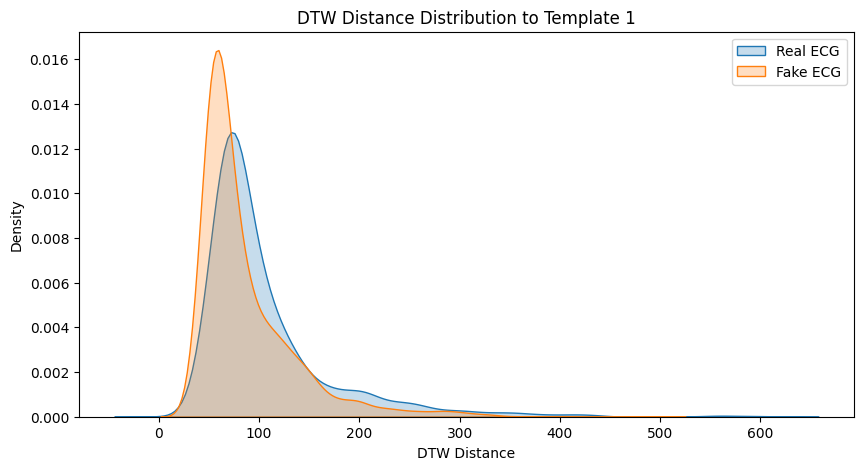

In [1]:
import os
import numpy as np
from tqdm import tqdm
from scipy.signal import resample
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. Load Real and Fake ECG Data from .asc Files
# =============================================================================

# Define the paths to your dataset directories
DATA_DIR_REAL = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/real_ecgs"
DATA_DIR_FAKE = "C:/Users/M2-Winterfell/Downloads/pulse2pulse_150k/from_006_chkp_2500_150k"

# Function to load and extract Lead I from a single .asc file
def load_lead_I_from_asc(file_path):
    try:
        ecg_data = np.loadtxt(file_path)
        # Assuming the first column is Lead I
        lead_I = ecg_data[:, 0]
        return lead_I
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# Function to load exactly n Lead I ECG records from a specified directory with a progress bar
def load_exactly_n_lead_I_from_directory(data_dir, n=2000):
    all_lead_I = []
    i = 0
    with tqdm(total=n, desc=f"Loading Lead I from {os.path.basename(data_dir)}", unit='file') as pbar:
        while len(all_lead_I) < n:
            file_name = f"{i}.asc"
            file_path = os.path.join(data_dir, file_name)
            if os.path.exists(file_path):
                lead_I = load_lead_I_from_asc(file_path)
                if lead_I is not None:
                    all_lead_I.append(lead_I)
                    pbar.update(1)
            i += 1
    return np.array(all_lead_I)

# Load exactly 2000 Lead I records from both real and fake datasets
lead_I_real = load_exactly_n_lead_I_from_directory(DATA_DIR_REAL, n=2000)
lead_I_fake = load_exactly_n_lead_I_from_directory(DATA_DIR_FAKE, n=2000)

if lead_I_real.size > 0 and lead_I_fake.size > 0:
    print(f"Total Lead I records loaded from real data: {lead_I_real.shape[0]}")
    print(f"Total Lead I records loaded from fake data: {lead_I_fake.shape[0]}")
else:
    print("No data was loaded.")

# =============================================================================
# 2. Preprocessing: Normalization and Downsampling
# =============================================================================

# Normalize each ECG signal between -1 and 1
def min_max_normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    return 2 * (data - min_val) / (max_val - min_val) - 1

# Normalize the real and fake signals
lead_I_real = np.array([min_max_normalize(ecg) for ecg in lead_I_real])
lead_I_fake = np.array([min_max_normalize(ecg) for ecg in lead_I_fake])

# Downsample each signal to 500 points (this makes computation of DTW distances more efficient)
downsampled_real = np.array([resample(ecg, 500) for ecg in lead_I_real])
downsampled_fake = np.array([resample(ecg, 500) for ecg in lead_I_fake])

# Combine real and fake data into a single dataset and create corresponding labels
all_data = np.concatenate([downsampled_real, downsampled_fake])
y = np.concatenate([np.ones(downsampled_real.shape[0]), np.zeros(downsampled_fake.shape[0])])

# =============================================================================
# 3. DTW Distance Matrix Computation and Feature Extraction
# =============================================================================

# Randomly select N real samples as DTW templates (here, 5 templates)
num_templates = 5
template_indices = np.random.choice(downsampled_real.shape[0], num_templates, replace=False)
templates = downsampled_real[template_indices]

# Custom DTW distance function to compute pairwise DTW distances between each sample and the templates
def dtw_distance_matrix(data, templates):
    n_samples = data.shape[0]
    n_templates = templates.shape[0]
    dist_matrix = np.zeros((n_samples, n_templates))
    
    for i in range(n_samples):
        for j in range(n_templates):
            sample = data[i]
            template = templates[j]
            
            # Convert the 1D signals into a list of tuples (this is required by fastdtw)
            sample_tuples = [(val, 0) for val in sample]
            template_tuples = [(val, 0) for val in template]
            
            distance, _ = fastdtw(sample_tuples, template_tuples, dist=euclidean)
            dist_matrix[i, j] = distance
            
    return dist_matrix

# Calculate DTW distances for each sample against all selected templates
X = dtw_distance_matrix(all_data, templates)

# =============================================================================
# 4. Classification using a Random Forest
# =============================================================================

# Split the DTW features and labels into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42)

# Train a Random Forest classifier with balanced class weights
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced')
clf.fit(X_train, y_train)

# Evaluate the classifier and print the classification report
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# =============================================================================
# 5. Visualization: Feature Importance and DTW Distance Distributions
# =============================================================================

# Plot feature importance (importance of each DTW template)
feature_importance = clf.feature_importances_
plt.figure(figsize=(10, 4))
sns.barplot(x=[f"Template_{i+1}" for i in range(num_templates)], y=feature_importance)
plt.title("DTW Template Importance")
plt.show()

# Plot the DTW distance distribution for one of the templates for both classes
# Clean the DTW distance matrix in case there are NaN or Inf values
X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
plt.figure(figsize=(10, 5))
sns.kdeplot(X_clean[y == 1, 0], label="Real ECG", fill=True)
sns.kdeplot(X_clean[y == 0, 0], label="Fake ECG", fill=True)
plt.title("DTW Distance Distribution to Template 1")
plt.xlabel("DTW Distance")
plt.legend()
plt.show()


Loading Lead I from pulse2pulse_fake: 100%|██████████| 1000/1000 [00:02<00:00, 347.79file/s]


Total Lead I records loaded from real data: 1000
Total Lead I records loaded from fake data: 1000
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.98       200
         1.0       0.98      0.98      0.98       200

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



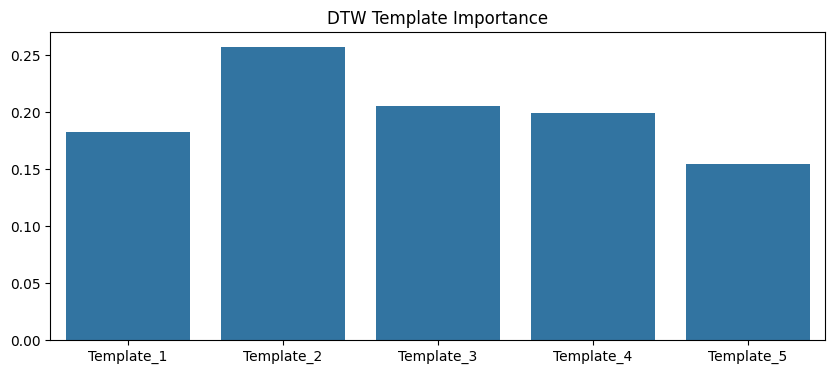

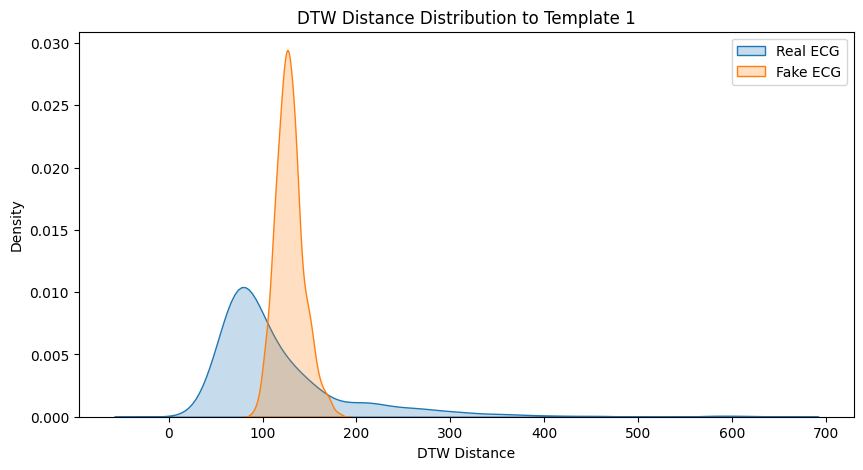

In [ ]:
import os
import numpy as np
from tqdm import tqdm
from scipy.signal import resample
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# 1. Load Real and Fake ECG Data from .asc Files
# =============================================================================

# Define the paths to your dataset directories
DATA_DIR_REAL = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/real_ecgs"
DATA_DIR_FAKE = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/pulse2pulse_fake"

# Function to load and extract Lead I from a single .asc file
def load_lead_I_from_asc(file_path):
    try:
        ecg_data = np.loadtxt(file_path)
        # Assuming the first column is Lead I
        lead_I = ecg_data[:, 0]
        return lead_I
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# Function to load exactly n Lead I ECG records from a specified directory with a progress bar
def load_exactly_n_lead_I_from_directory(data_dir, n=1000):
    all_lead_I = []
    i = 0
    with tqdm(total=n, desc=f"Loading Lead I from {os.path.basename(data_dir)}", unit='file') as pbar:
        while len(all_lead_I) < n:
            file_name = f"{i}.asc"
            file_path = os.path.join(data_dir, file_name)
            if os.path.exists(file_path):
                lead_I = load_lead_I_from_asc(file_path)
                if lead_I is not None:
                    all_lead_I.append(lead_I)
                    pbar.update(1)
            i += 1
    return np.array(all_lead_I)

# Load exactly 2000 Lead I records from both real and fake datasets
lead_I_real = load_exactly_n_lead_I_from_directory(DATA_DIR_REAL, n=1000)
lead_I_fake = load_exactly_n_lead_I_from_directory(DATA_DIR_FAKE, n=1000)

if lead_I_real.size > 0 and lead_I_fake.size > 0:
    print(f"Total Lead I records loaded from real data: {lead_I_real.shape[0]}")
    print(f"Total Lead I records loaded from fake data: {lead_I_fake.shape[0]}")
else:
    print("No data was loaded.")

# =============================================================================
# 2. Preprocessing: Normalization and Downsampling
# =============================================================================

# Normalize each ECG signal between -1 and 1
def min_max_normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    return 2 * (data - min_val) / (max_val - min_val) - 1

# Normalize the real and fake signals
lead_I_real = np.array([min_max_normalize(ecg) for ecg in lead_I_real])
lead_I_fake = np.array([min_max_normalize(ecg) for ecg in lead_I_fake])

# Downsample each signal to 500 points (this makes computation of DTW distances more efficient)
downsampled_real = np.array([resample(ecg, 500) for ecg in lead_I_real])
downsampled_fake = np.array([resample(ecg, 500) for ecg in lead_I_fake])

# Combine real and fake data into a single dataset and create corresponding labels
all_data = np.concatenate([downsampled_real, downsampled_fake])
y = np.concatenate([np.ones(downsampled_real.shape[0]), np.zeros(downsampled_fake.shape[0])])

# =============================================================================
# 3. DTW Distance Matrix Computation and Feature Extraction
# =============================================================================

# Randomly select N real samples as DTW templates (here, 5 templates)
num_templates = 5
template_indices = np.random.choice(downsampled_real.shape[0], num_templates, replace=False)
templates = downsampled_real[template_indices]

# Custom DTW distance function to compute pairwise DTW distances between each sample and the templates
def dtw_distance_matrix(data, templates):
    n_samples = data.shape[0]
    n_templates = templates.shape[0]
    dist_matrix = np.zeros((n_samples, n_templates))
    
    for i in range(n_samples):
        for j in range(n_templates):
            sample = data[i]
            template = templates[j]
            
            # Convert the 1D signals into a list of tuples (this is required by fastdtw)
            sample_tuples = [(val, 0) for val in sample]
            template_tuples = [(val, 0) for val in template]
            
            distance, _ = fastdtw(sample_tuples, template_tuples, dist=euclidean)
            dist_matrix[i, j] = distance
            
    return dist_matrix

# Calculate DTW distances for each sample against all selected templates
X = dtw_distance_matrix(all_data, templates)

# =============================================================================
# 4. Classification using a Random Forest
# =============================================================================

# Split the DTW features and labels into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=42)

# Train a Random Forest classifier with balanced class weights
clf = RandomForestClassifier(n_estimators=100, class_weight='balanced')
clf.fit(X_train, y_train)

# Evaluate the classifier and print the classification report
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# =============================================================================
# 5. Visualization: Feature Importance and DTW Distance Distributions
# =============================================================================

# Plot feature importance (importance of each DTW template)
feature_importance = clf.feature_importances_
plt.figure(figsize=(10, 4))
sns.barplot(x=[f"Template_{i+1}" for i in range(num_templates)], y=feature_importance)
plt.title("DTW Template Importance")
plt.show()

# Plot the DTW distance distribution for one of the templates for both classes
# Clean the DTW distance matrix in case there are NaN or Inf values
X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
plt.figure(figsize=(10, 5))
sns.kdeplot(X_clean[y == 1, 0], label="Real ECG", fill=True)
sns.kdeplot(X_clean[y == 0, 0], label="Fake ECG", fill=True)
plt.title("DTW Distance Distribution to Template 1")
plt.xlabel("DTW Distance")
plt.legend()
plt.show()


Loading Lead I from from_006_chkp_2500_150k: 100%|██████████| 2000/2000 [00:08<00:00, 222.74file/s]


Total Lead I records loaded from real data: 2000
Total Lead I records loaded from fake data: 2000


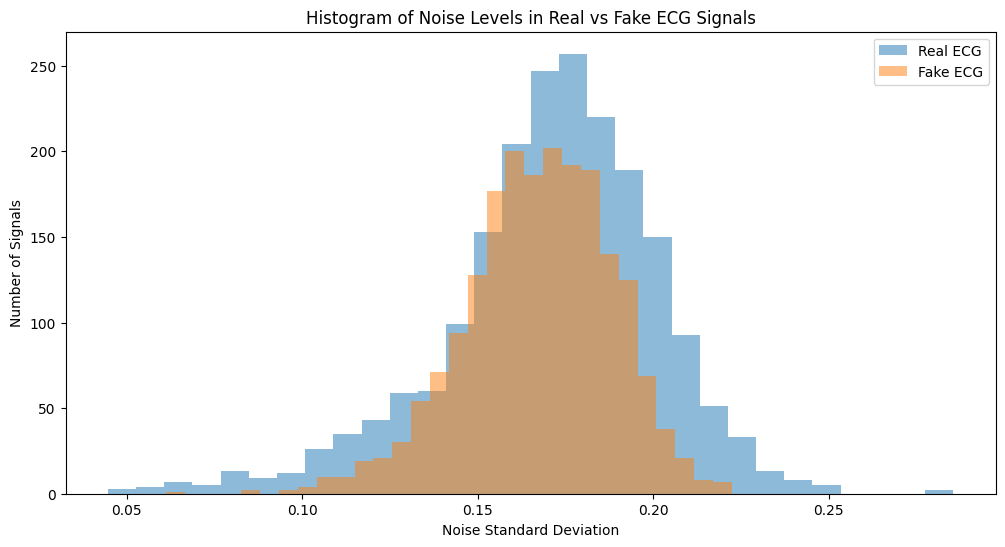

C:\Users\M2-Winterfell\AppData\Local\Temp\ipykernel_9988\1285089950.py:114: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([noise_std_real, noise_std_fake], labels=["Real ECG", "Fake ECG"])


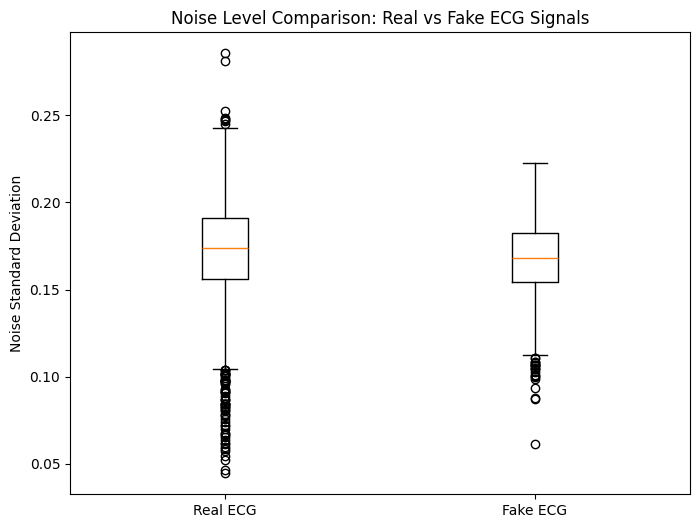

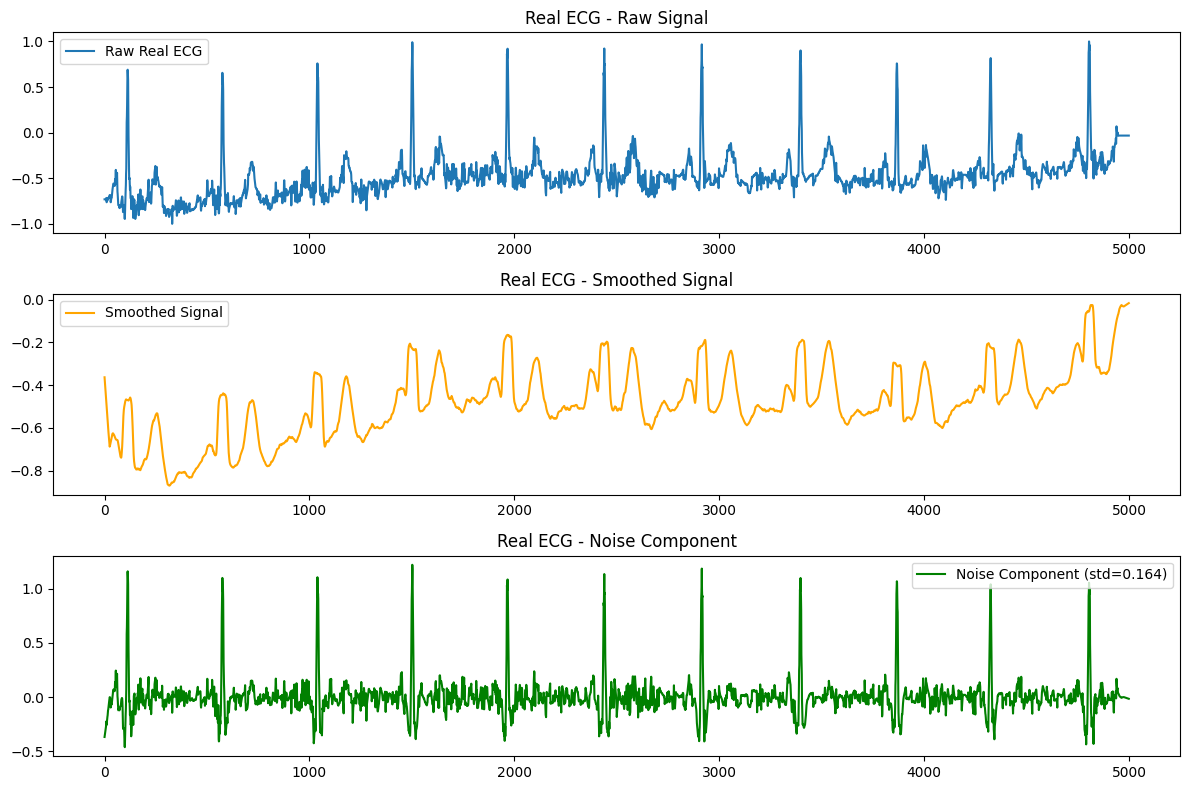

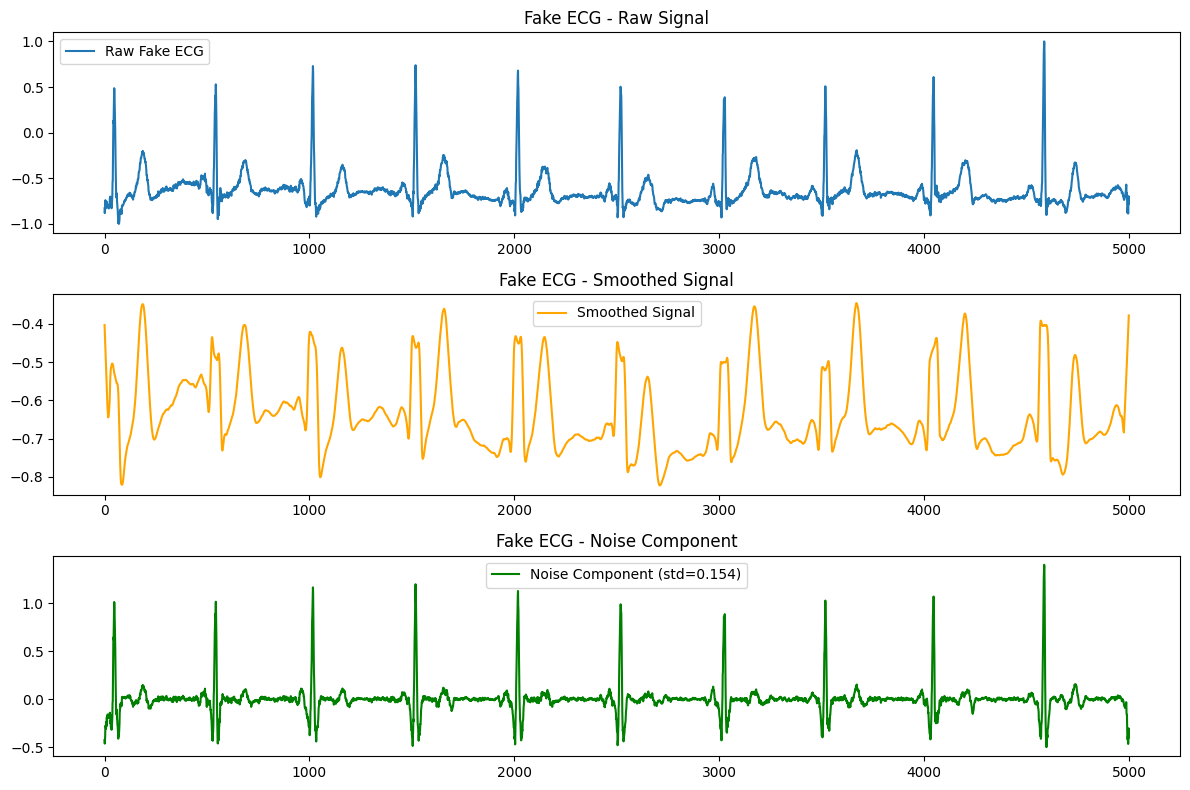

In [1]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -------------------------------
# Data Loading and Preprocessing
# -------------------------------

# Define the paths to your dataset directories
DATA_DIR_FAKE = "C:/Users/M2-Winterfell/Downloads/pulse2pulse_150k/from_006_chkp_2500_150k"
DATA_DIR_REAL = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/real_ecgs"

# Function to load and extract Lead I from a single .asc file
def load_lead_I_from_asc(file_path):
    try:
        # Load the .asc file (assuming it's space or tab-delimited)
        ecg_data = np.loadtxt(file_path)
        # Extract Lead I (assuming first column is Lead I)
        lead_I = ecg_data[:, 0]
        return lead_I
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# Function to load exactly n Lead I ECG records from a specified directory with a progress bar
def load_exactly_n_lead_I_from_directory(data_dir, n=2000):
    all_lead_I = []
    i = 0
    with tqdm(total=n, desc=f"Loading Lead I from {os.path.basename(data_dir)}", unit='file') as pbar:
        while len(all_lead_I) < n:
            file_name = f"{i}.asc"
            file_path = os.path.join(data_dir, file_name)
            if os.path.exists(file_path):
                lead_I = load_lead_I_from_asc(file_path)
                if lead_I is not None:
                    all_lead_I.append(lead_I)
                    pbar.update(1)
            i += 1
    return np.array(all_lead_I)

# Load exactly 2000 Lead I ECG records from both directories
lead_I_real = load_exactly_n_lead_I_from_directory(DATA_DIR_REAL, n=2000)
lead_I_fake = load_exactly_n_lead_I_from_directory(DATA_DIR_FAKE, n=2000)

if lead_I_fake.size > 0 and lead_I_real.size > 0:
    print(f"Total Lead I records loaded from real data: {lead_I_real.shape[0]}")
    print(f"Total Lead I records loaded from fake data: {lead_I_fake.shape[0]}")
else:
    print("No data was loaded.")

# Normalize each ECG signal between -1 and 1
def min_max_normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    return 2 * (data - min_val) / (max_val - min_val) - 1

lead_I_real = np.array([min_max_normalize(ecg) for ecg in lead_I_real])
lead_I_fake = np.array([min_max_normalize(ecg) for ecg in lead_I_fake])

# -------------------------------
# Noise Detection and Visualization
# -------------------------------

# Here we define a function to estimate the "noise" in each ECG signal.
# The idea is to smooth the signal with a moving average filter (as a simple low-pass filter)
# and then compute the standard deviation of the difference between the original and the smoothed signal.
def compute_noise_std(signal, window_size=50):
    # Compute a moving average to obtain a smooth version of the signal.
    # Adjust window_size if needed to best capture the underlying trend.
    smooth_signal = np.convolve(signal, np.ones(window_size)/window_size, mode='same')
    noise_component = signal - smooth_signal
    noise_std = np.std(noise_component)
    return noise_std, smooth_signal, noise_component

# Compute the noise standard deviation for each signal in both datasets.
noise_std_real = []
for signal in lead_I_real:
    noise_std, _, _ = compute_noise_std(signal, window_size=50)
    noise_std_real.append(noise_std)

noise_std_fake = []
for signal in lead_I_fake:
    noise_std, _, _ = compute_noise_std(signal, window_size=50)
    noise_std_fake.append(noise_std)

# Convert lists to numpy arrays for further processing if needed.
noise_std_real = np.array(noise_std_real)
noise_std_fake = np.array(noise_std_fake)

# -------------------------------
# Visualization
# -------------------------------

# 1. Histogram of noise levels for real vs fake ECG signals
plt.figure(figsize=(12, 6))
plt.hist(noise_std_real, bins=30, alpha=0.5, label="Real ECG")
plt.hist(noise_std_fake, bins=30, alpha=0.5, label="Fake ECG")
plt.xlabel("Noise Standard Deviation")
plt.ylabel("Number of Signals")
plt.title("Histogram of Noise Levels in Real vs Fake ECG Signals")
plt.legend()
plt.show()

# 2. Boxplot to compare the noise distributions
plt.figure(figsize=(8, 6))
plt.boxplot([noise_std_real, noise_std_fake], labels=["Real ECG", "Fake ECG"])
plt.ylabel("Noise Standard Deviation")
plt.title("Noise Level Comparison: Real vs Fake ECG Signals")
plt.show()

# 3. Plot sample signals and their noise components
# Let's visualize one sample from each category (you can loop or pick more samples as needed)

sample_index = 0  # change index to see different samples

# For a real ECG sample
real_signal = lead_I_real[sample_index]
real_noise_std, real_smooth, real_noise = compute_noise_std(real_signal, window_size=50)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(real_signal, label="Raw Real ECG")
plt.title("Real ECG - Raw Signal")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(real_smooth, label="Smoothed Signal", color='orange')
plt.title("Real ECG - Smoothed Signal")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(real_noise, label=f"Noise Component (std={real_noise_std:.3f})", color='green')
plt.title("Real ECG - Noise Component")
plt.legend()

plt.tight_layout()
plt.show()

# For a fake ECG sample
fake_signal = lead_I_fake[sample_index]
fake_noise_std, fake_smooth, fake_noise = compute_noise_std(fake_signal, window_size=50)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(fake_signal, label="Raw Fake ECG")
plt.title("Fake ECG - Raw Signal")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(fake_smooth, label="Smoothed Signal", color='orange')
plt.title("Fake ECG - Smoothed Signal")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(fake_noise, label=f"Noise Component (std={fake_noise_std:.3f})", color='green')
plt.title("Fake ECG - Noise Component")
plt.legend()

plt.tight_layout()
plt.show()

# -------------------------------
# Interpretation
# -------------------------------
#
# You can compare the histograms and boxplots to see if one dataset has consistently higher or more variable noise levels.
# For instance, if the real ECG signals show a higher average noise standard deviation than the fake ones,
# that could be an indication of the natural myoelectric interference and baseline drift present in real data.
#
# Keep in mind that this method (a simple moving average subtraction) is one way to quantify noise.
# Depending on your application, you might consider more advanced noise estimation techniques or frequency-domain analyses.


Loading Lead I from timegan_fake: 100%|██████████| 1000/1000 [00:12<00:00, 78.60file/s]


Total Lead I records loaded from real data: 1000
Total Lead I records loaded from fake data: 1000


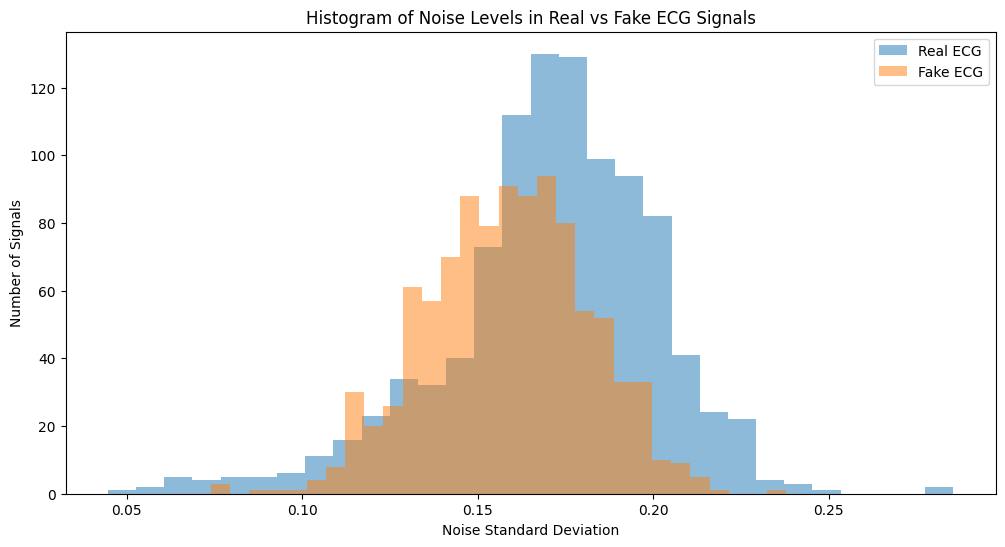

C:\Users\M2-Winterfell\AppData\Local\Temp\ipykernel_17764\1010436071.py:142: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([noise_std_real, noise_std_fake], labels=["Real ECG", "Fake ECG"])


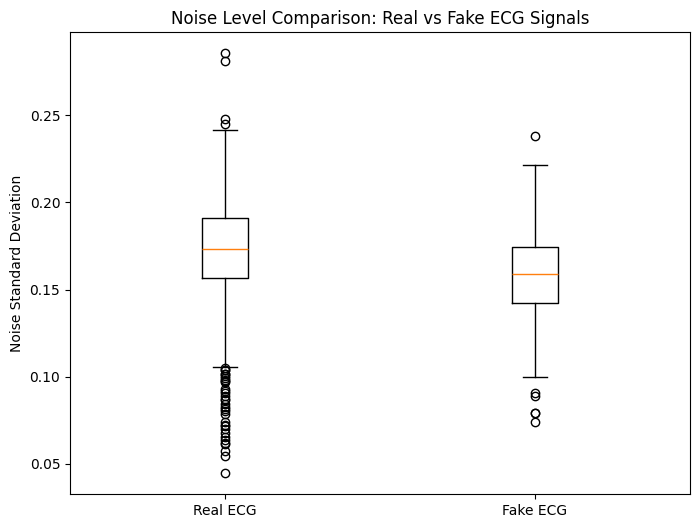

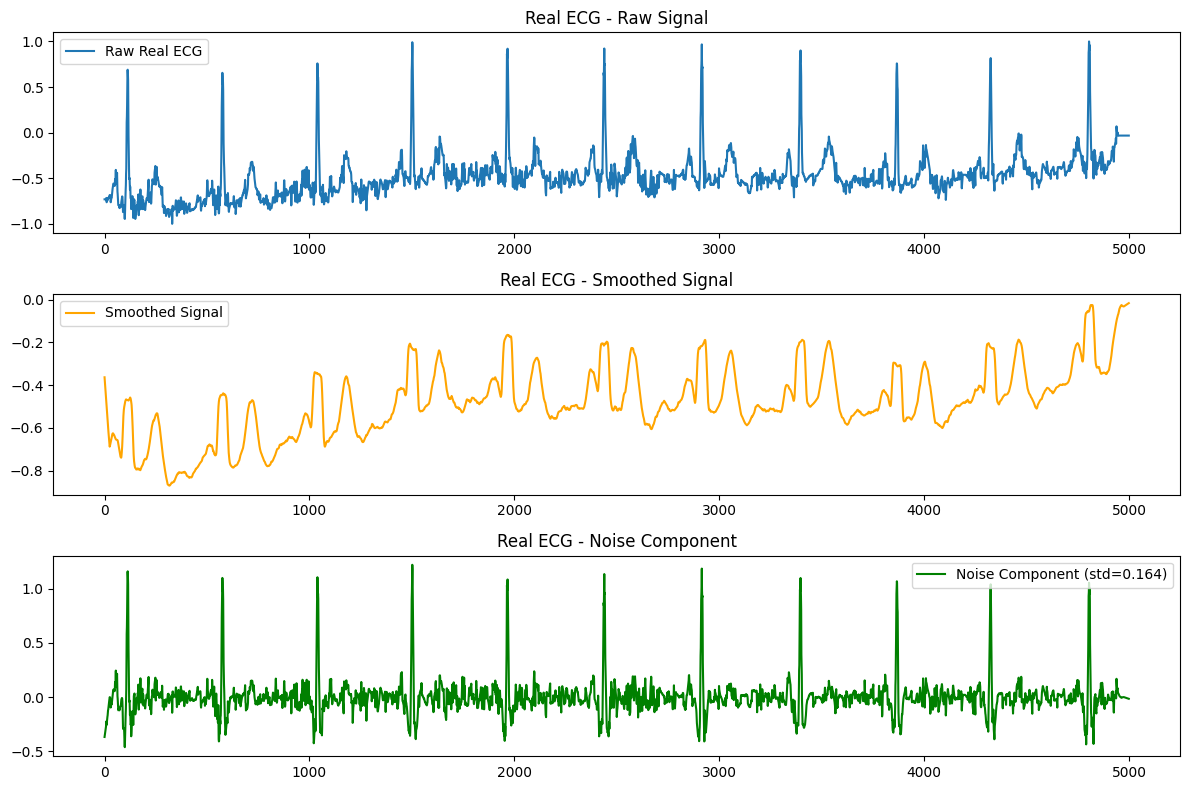

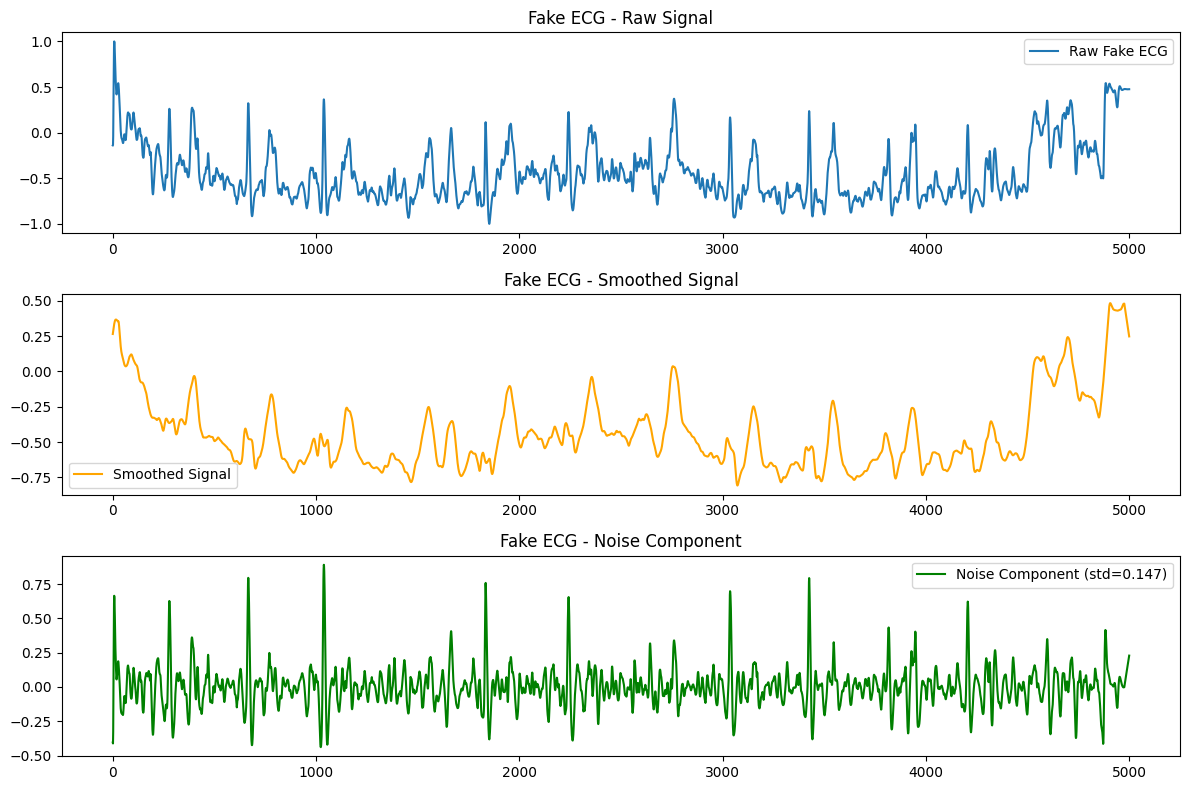

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# -------------------------------
# Data Loading and Preprocessing
# -------------------------------

# Define the paths to your dataset directories
DATA_DIR_FAKE = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/timegan_fake"
DATA_DIR_REAL = "C:/Users/M2-Winterfell/Downloads/GAN-models-for-Bio-Authentication-through-ECG-signals/datasets/real_ecgs"

# Function to load and extract Lead I from a single .asc file
def load_lead_I_from_asc(file_path):
    try:
        # Load the .asc file (assuming it's space or tab-delimited)
        ecg_data = np.loadtxt(file_path)
        # Extract Lead I (assuming first column is Lead I)
        lead_I = ecg_data[:, 0]
        return lead_I
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None

# Function to load exactly n Lead I ECG records from a specified directory with a progress bar
def load_exactly_n_lead_I_from_directory(data_dir, n=1000):
    all_lead_I = []
    i = 0
    with tqdm(total=n, desc=f"Loading Lead I from {os.path.basename(data_dir)}", unit='file') as pbar:
        while len(all_lead_I) < n:
            file_name = f"{i}.asc"
            file_path = os.path.join(data_dir, file_name)
            if os.path.exists(file_path):
                lead_I = load_lead_I_from_asc(file_path)
                if lead_I is not None:
                    all_lead_I.append(lead_I)
                    pbar.update(1)
            i += 1
    return np.array(all_lead_I)

# Load exactly 2000 Lead I ECG records from both directories
lead_I_real = load_exactly_n_lead_I_from_directory(DATA_DIR_REAL, n=1000)
lead_I_fake = load_exactly_n_lead_I_from_directory(DATA_DIR_FAKE, n=1000)

if lead_I_fake.size > 0 and lead_I_real.size > 0:
    print(f"Total Lead I records loaded from real data: {lead_I_real.shape[0]}")
    print(f"Total Lead I records loaded from fake data: {lead_I_fake.shape[0]}")
else:
    print("No data was loaded.")

# Normalize each ECG signal between -1 and 1
def min_max_normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    return 2 * (data - min_val) / (max_val - min_val) - 1

lead_I_real = np.array([min_max_normalize(ecg) for ecg in lead_I_real])
lead_I_fake = np.array([min_max_normalize(ecg) for ecg in lead_I_fake])

# -------------------------------
# Noise Detection and Visualization
# -------------------------------

# Here we define a function to estimate the "noise" in each ECG signal.
# The idea is to smooth the signal with a moving average filter (as a simple low-pass filter)
# and then compute the standard deviation of the difference between the original and the smoothed signal.
def compute_noise_std(signal, window_size=50):
    # Compute a moving average to obtain a smooth version of the signal.
    # Adjust window_size if needed to best capture the underlying trend.
    smooth_signal = np.convolve(signal, np.ones(window_size)/window_size, mode='same')
    noise_component = signal - smooth_signal
    noise_std = np.std(noise_component)
    return noise_std, smooth_signal, noise_component

# Compute the noise standard deviation for each signal in both datasets.
noise_std_real = []
for signal in lead_I_real:
    noise_std, _, _ = compute_noise_std(signal, window_size=50)
    noise_std_real.append(noise_std)

noise_std_fake = []
for signal in lead_I_fake:
    noise_std, _, _ = compute_noise_std(signal, window_size=50)
    noise_std_fake.append(noise_std)

# Convert lists to numpy arrays for further processing if needed.
noise_std_real = np.array(noise_std_real)
noise_std_fake = np.array(noise_std_fake)

# -------------------------------
# Visualization
# -------------------------------

# 1. Histogram of noise levels for real vs fake ECG signals
plt.figure(figsize=(12, 6))
plt.hist(noise_std_real, bins=30, alpha=0.5, label="Real ECG")
plt.hist(noise_std_fake, bins=30, alpha=0.5, label="Fake ECG")
plt.xlabel("Noise Standard Deviation")
plt.ylabel("Number of Signals")
plt.title("Histogram of Noise Levels in Real vs Fake ECG Signals")
plt.legend()
plt.show()

# 2. Boxplot to compare the noise distributions
plt.figure(figsize=(8, 6))
plt.boxplot([noise_std_real, noise_std_fake], labels=["Real ECG", "Fake ECG"])
plt.ylabel("Noise Standard Deviation")
plt.title("Noise Level Comparison: Real vs Fake ECG Signals")
plt.show()

# 3. Plot sample signals and their noise components
# Let's visualize one sample from each category (you can loop or pick more samples as needed)

sample_index = 0  # change index to see different samples

# For a real ECG sample
real_signal = lead_I_real[sample_index]
real_noise_std, real_smooth, real_noise = compute_noise_std(real_signal, window_size=50)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(real_signal, label="Raw Real ECG")
plt.title("Real ECG - Raw Signal")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(real_smooth, label="Smoothed Signal", color='orange')
plt.title("Real ECG - Smoothed Signal")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(real_noise, label=f"Noise Component (std={real_noise_std:.3f})", color='green')
plt.title("Real ECG - Noise Component")
plt.legend()

plt.tight_layout()
plt.show()

# For a fake ECG sample
fake_signal = lead_I_fake[sample_index]
fake_noise_std, fake_smooth, fake_noise = compute_noise_std(fake_signal, window_size=50)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(fake_signal, label="Raw Fake ECG")
plt.title("Fake ECG - Raw Signal")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(fake_smooth, label="Smoothed Signal", color='orange')
plt.title("Fake ECG - Smoothed Signal")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(fake_noise, label=f"Noise Component (std={fake_noise_std:.3f})", color='green')
plt.title("Fake ECG - Noise Component")
plt.legend()

plt.tight_layout()
plt.show()

# -------------------------------
# Interpretation
# -------------------------------
#
# You can compare the histograms and boxplots to see if one dataset has consistently higher or more variable noise levels.
# For instance, if the real ECG signals show a higher average noise standard deviation than the fake ones,
# that could be an indication of the natural myoelectric interference and baseline drift present in real data.
#
# Keep in mind that this method (a simple moving average subtraction) is one way to quantify noise.
# Depending on your application, you might consider more advanced noise estimation techniques or frequency-domain analyses.
